In [1]:
import pandas as pd
import gseapy as gp

res = pd.read_csv(
    "/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-output/d4_pcs_deseq2_results.csv",
    index_col=0
)


In [2]:


# Start from your DESeq2 results
res_clean = res.copy()

# Drop genes without a statistic or padj
res_clean = res_clean.dropna(subset=["stat", "log2FoldChange", "padj"])


In [3]:
# Use the Wald test statistic as the ranking score
res_clean["score"] = res_clean["stat"]


In [4]:
rnk = res_clean[["score"]].sort_values("score", ascending=False)


In [5]:
pre_res = gp.prerank(
    rnk=rnk,                          # genes in index, 1 col of scores
    gene_sets="GO_Biological_Process_2021",  # or KEGG, Reactome, etc.
    outdir="gsea_iscs",
    min_size=15,
    max_size=500,
    permutation_num=1000,
    seed=42,
)

2025-11-21 10:25:08,370 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [6]:
pre_res_hallmark = gp.prerank(
    rnk=rnk,
    gene_sets="MSigDB_Hallmark_2020",
    outdir="gsea_iscs_hallmark",
    min_size=10,
    max_size=500,
    permutation_num=1000,
    seed=42,
)


2025-11-21 10:25:40,711 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [7]:
hallmark_ifn_inflam = pre_res_hallmark.res2d[
    pre_res_hallmark.res2d["Term"].str.contains("INTERFERON|INFLAMMATORY", case=False)
]
hallmark_ifn_inflam


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
26,prerank,Interferon Alpha Response,-0.452515,-1.753652,0.0,0.000665,0.014,40/95,25.09%,ISG20;OAS1;PSMA3;PROCR;OASL;IFI27;LY6E;TRIM25;...
34,prerank,Inflammatory Response,-0.329085,-1.392125,0.025157,0.039001,0.62,52/146,22.95%,F3;PLAUR;ADORA2B;AHR;CXCL8;LIF;TIMP1;IL18;RGS1...
35,prerank,Interferon Gamma Response,-0.317244,-1.341606,0.029593,0.061063,0.776,59/177,24.31%,ISG20;PNP;PIM1;OAS3;METTL7B;PSMB2;PSMA3;PFKP;O...


In [8]:
egfr_markers = [
    "FOS", "FOSB", "JUN", "JUNB", "JUND",
    "EGR1", "EGR2", "EGR3",
    "DUSP4", "DUSP6",
    "MYC",
    "CCND1", "MCL1",
    "AREG", "EREG", "HBEGF"
]

res.loc[res.index.intersection(egfr_markers)].sort_values("log2FoldChange")


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
EREG,376.865418,-3.336844,0.590954,-5.646537,1.637123e-08,3.181088e-07
AREG,3699.188695,-3.051707,0.896356,-3.404571,6.626804e-04,3.169124e-03
CCND1,5236.569551,-1.629352,0.303332,-5.371520,7.807591e-08,1.258862e-06
DUSP4,2323.071430,-1.394907,0.188449,-7.402034,1.341137e-13,7.637118e-12
DUSP6,718.982585,-1.276660,0.270637,-4.717235,2.390716e-06,2.593848e-05
JUND,5319.757533,-0.853674,0.250438,-3.408729,6.526621e-04,3.137205e-03
MYC,898.369767,-0.818567,0.345064,-2.372217,1.768169e-02,4.852121e-02
HBEGF,395.413190,-0.411697,0.419114,-0.982302,3.259509e-01,4.743490e-01
MCL1,1762.033601,-0.222874,0.150133,-1.484510,1.376737e-01,2.492498e-01
JUNB,1197.686131,-0.081240,0.251034,-0.323619,7.462263e-01,8.338338e-01


Term
False    47
True      3
Name: count, dtype: int64


/var/folders/h4/gmb18r416rs2h3sdc7knc0500000gn/T/ipykernel_2239/2288291605.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


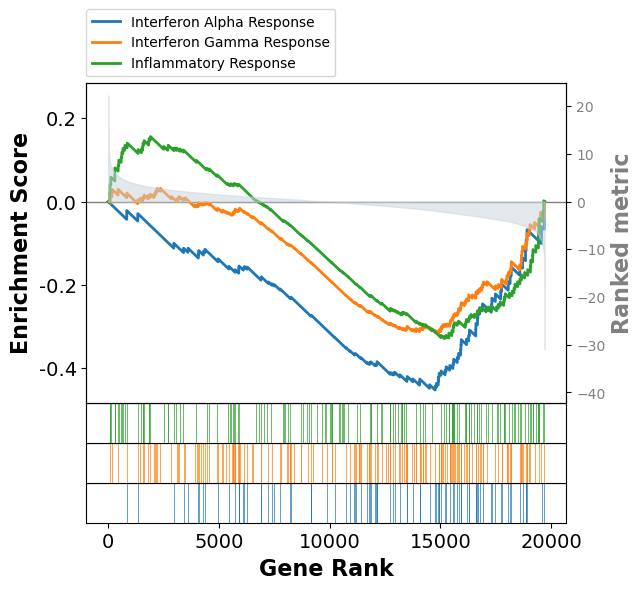

In [9]:
import matplotlib.pyplot as plt

# Terms of interest (must match pre_res_hallmark.res2d["Term"])
terms_of_interest = [
    "Interferon Alpha Response",
    "Interferon Gamma Response",
    "Inflammatory Response",
]

# Quick check they exist
print(pre_res_hallmark.res2d["Term"].isin(terms_of_interest).value_counts())

# 1A. Built-in multi-panel GSEA plot
axs = pre_res_hallmark.plot(
    terms=terms_of_interest,
    show_ranking=True,          # show ranked genes underneath
    figsize=(6, 8),
    ofname=None                 # or "iscs_gsea_ifn_inflam.pdf"
)
plt.tight_layout()
